In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.fft import fft2, fftshift
from scipy.signal import find_peaks

# Функция для проверки перекрытия кружков
def check_overlap(existing_circles, new_center, new_radius, min_distance_factor=1.2):
    for center, radius in existing_circles:
        distance = np.sqrt((new_center[0] - center[0])**2 + (new_center[1] - center[1])**2)
        if distance < (new_radius + radius) * min_distance_factor:
            return True
    return False

# Функция для генерации изображения
def generate_image(diameters, counts, noise_diameter, noise_count):
    image = np.zeros((512, 512), dtype=np.float32)
    existing_circles = []
    
    # Генерация основных кружков
    for diameter, count in zip(diameters, counts):
        radius = diameter // 2
        attempts = 0
        max_attempts = 1000
        
        for _ in range(count):
            placed = False
            attempts = 0
            while not placed and attempts < max_attempts:
                x = np.random.randint(radius, 512 - radius)
                y = np.random.randint(radius, 512 - radius)
                
                if not check_overlap(existing_circles, (x, y), radius):
                    yy, xx = np.ogrid[:512, :512]
                    circle = (xx - x)**2 + (yy - y)**2 <= radius**2
                    image[circle] = 1.0
                    existing_circles.append(((x, y), radius))
                    placed = True
                attempts += 1
    
    # Добавление шума в виде кружков
    noise_radius = noise_diameter // 2
    for _ in range(noise_count):
        attempts = 0
        placed = False
        while not placed and attempts < max_attempts:
            x = np.random.randint(noise_radius, 512 - noise_radius)
            y = np.random.randint(noise_radius, 512 - noise_radius)
            
            yy, xx = np.ogrid[:512, :512]
            circle = (xx - x)**2 + (yy - y)**2 <= noise_radius**2
            image[circle] = 1.0
            placed = True
            attempts += 1
    
    return image

# Функция для вычисления Фурье-преобразования и радиального среза
def compute_fourier_and_slice(image, angle_deg):
    f_transform = fft2(image)
    f_shift = fftshift(f_transform)
    magnitude_spectrum = np.abs(f_shift)**2  # Квадрат модуля для картинки и среза
    
    # Радиальный срез
    center = np.array(magnitude_spectrum.shape) // 2
    angle_rad = np.deg2rad(angle_deg)
    length = min(center)
    r = np.arange(length)
    x = center[1] + r * np.cos(angle_rad)
    y = center[0] + r * np.sin(angle_rad)
    
    from scipy.ndimage import map_coordinates
    radial_slice = map_coordinates(magnitude_spectrum, [y, x], order=1)
    
    return magnitude_spectrum, radial_slice, r

# Функция для анализа радиального среза
def analyze_radial_slice(radial_slice, r):
    # Поиск пиков и минимумов
    peaks, _ = find_peaks(radial_slice)
    minima, _ = find_peaks(-radial_slice)
    
    # Значения первых 10 максимумов и минимумов
    max_values = [(r[i], radial_slice[i]) for i in peaks[:10]]
    min_values = [(r[i], radial_slice[i]) for i in minima[:10]]
    
    # Площадь под графиком (интеграл)
    area = np.trapz(radial_slice, r)
    
    # Средняя амплитуда и стандартное отклонение
    mean_amplitude = np.mean(radial_slice)
    std_amplitude = np.std(radial_slice)
    
    # Оценка частоты основного пика (если есть хотя бы 2 пика)
    dominant_frequency = 0
    if len(peaks) >= 2:
        peak_distances = np.diff(r[peaks])
        dominant_frequency = 1 / np.mean(peak_distances) if peak_distances.size > 0 else 0
    
    return {
        'num_peaks': len(peaks),
        'num_minima': len(minima),
        'max_values': max_values,
        'min_values': min_values,
        'area': area,
        'mean_amplitude': mean_amplitude,
        'std_amplitude': std_amplitude,
        'dominant_frequency': dominant_frequency
    }

# Интерактивная функция для отображения
def plot_image_and_spectrum(diameter_1, count_1, diameter_2, count_2, diameter_3, count_3, noise_diameter, noise_count, angles):
    clear_output(wait=True)
    
    # Собираем диаметры и количества
    diameters = [d for d, c in [(diameter_1, count_1), (diameter_2, count_2), (diameter_3, count_3)] if c > 0]
    counts = [c for c in [count_1, count_2, count_3] if c > 0]
    
    # Генерация изображения
    image = generate_image(diameters, counts, noise_diameter, noise_count)
    
    # Создание графиков
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])
    
    # Изображение
    ax1.imshow(image, cmap='gray')
    ax1.set_title('Сгенерированное изображение', fontsize=16)
    ax1.axis('off')
    
    # Спектр Фурье (квадрат модуля)
    magnitude_spectrum, radial_slice, r = compute_fourier_and_slice(image, angles[0])
    ax2.imshow(magnitude_spectrum, cmap='viridis')
    ax2.set_title('Квадрат модуля спектра Фурье', fontsize=16)
    ax2.axis('off')
    
    # Радиальные срезы (квадрат модуля)
    analysis_results = []
    for angle in angles:
        _, radial_slice, r = compute_fourier_and_slice(image, angle)
        ax3.plot(r, radial_slice, label=f'Угол {angle}°', linewidth=2)
        analysis_results.append(analyze_radial_slice(radial_slice, r))
    
    ax3.set_title('Радиальный срез', fontsize=16)
    ax3.set_xlabel('Радиус, пиксели', fontsize=14)
    ax3.set_ylabel('Квадрат модуля Фурье, ед. интенсивности', fontsize=14)
    ax3.legend(fontsize=12)
    ax3.grid(True)
    ax3.tick_params(axis='both', labelsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод аналитической информации
    print("Анализ радиальных срезов:")
    for i, (angle, result) in enumerate(zip(angles, analysis_results)):
        print(f"\nУгол {angle}°:")
        print(f"Количество максимумов: {result['num_peaks']}")
        print(f"Количество минимумов: {result['num_minima']}")
        print(f"Первые 10 максимумов (радиус, значение): {result['max_values']}")
        print(f"Первые 10 минимумов (радиус, значение): {result['min_values']}")
        print(f"Площадь под графиком: {result['area']:.2e}")
        print(f"Средняя амплитуда: {result['mean_amplitude']:.2e}")
        print(f"Стандартное отклонение амплитуды: {result['std_amplitude']:.2e}")
        print(f"Частота основного пика (1/пиксель): {result['dominant_frequency']:.2e}")

# Создание виджетов
diameter_1_slider = widgets.IntSlider(value=10, min=5, max=100, step=1, description='Диаметр 1:')
count_1_slider = widgets.IntSlider(value=5, min=0, max=50, step=1, description='Кол-во 1:')
diameter_2_slider = widgets.IntSlider(value=20, min=5, max=100, step=1, description='Диаметр 2:')
count_2_slider = widgets.IntSlider(value=5, min=0, max=50, step=1, description='Кол-во 2:')
diameter_3_slider = widgets.IntSlider(value=30, min=5, max=100, step=1, description='Диаметр 3:')
count_3_slider = widgets.IntSlider(value=5, min=0, max=50, step=1, description='Кол-во 3:')
noise_diameter_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Диаметр шума:')
noise_count_slider = widgets.IntSlider(value=10, min=0, max=100, step=1, description='Кол-во шума:')
angles_widget = widgets.SelectMultiple(
    options=list(range(0, 360, 10)),
    value=[0],
    description='Углы:',
    layout={'height': '150px'}
)

# Интерактивный интерфейс
interactive_plot = widgets.interactive(
    plot_image_and_spectrum,
    diameter_1=diameter_1_slider,
    count_1=count_1_slider,
    diameter_2=diameter_2_slider,
    count_2=count_2_slider,
    diameter_3=diameter_3_slider,
    count_3=count_3_slider,
    noise_diameter=noise_diameter_slider,
    noise_count=noise_count_slider,
    angles=angles_widget
)

# Отображение интерфейса
display(interactive_plot)

interactive(children=(IntSlider(value=10, description='Диаметр 1:', min=5), IntSlider(value=5, description='Ко…

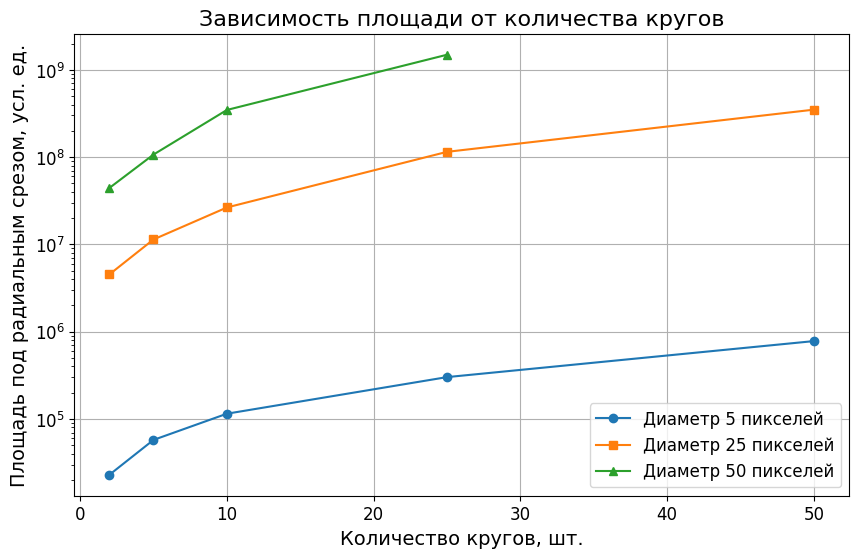

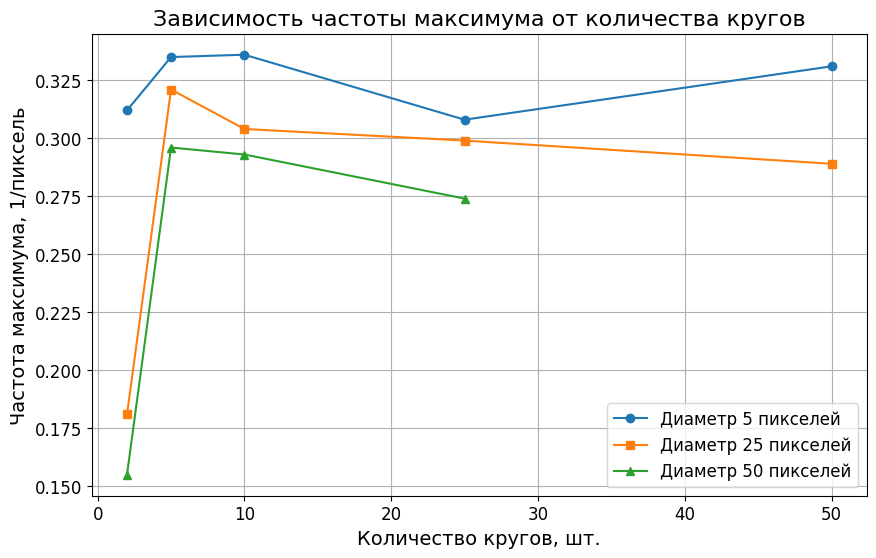

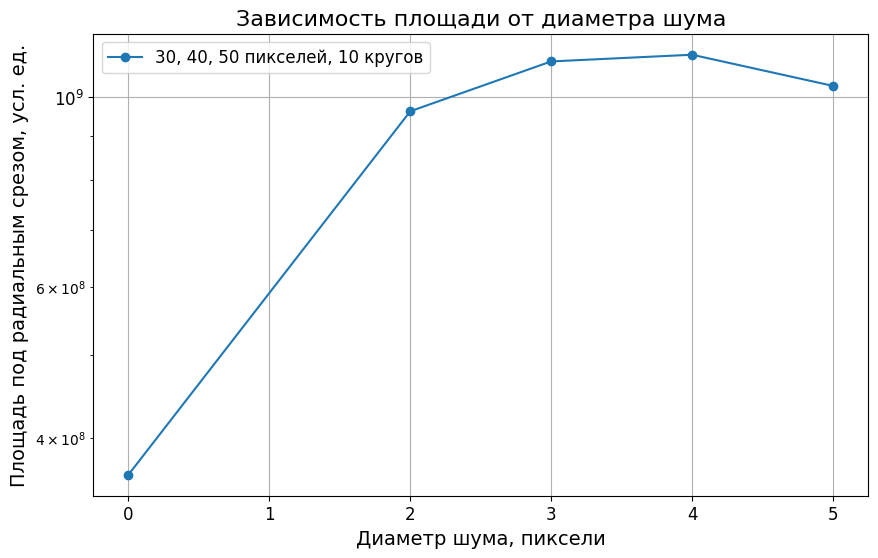

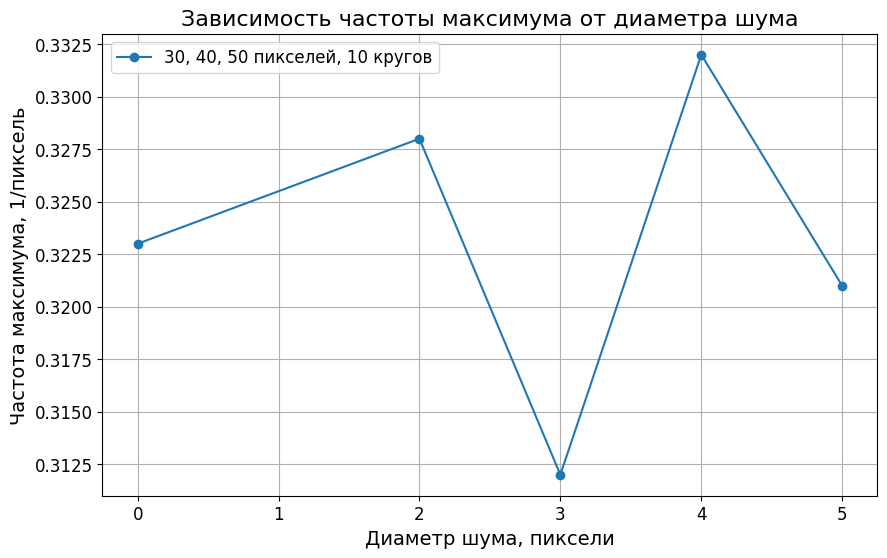

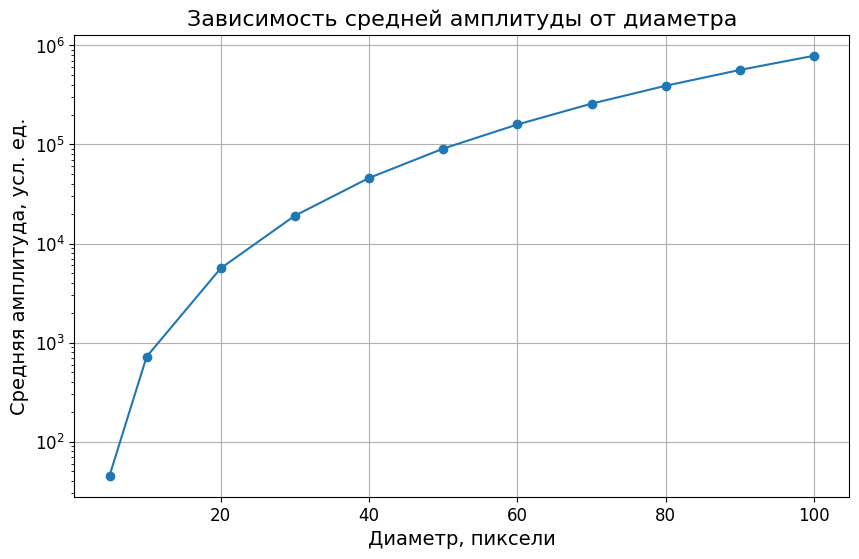

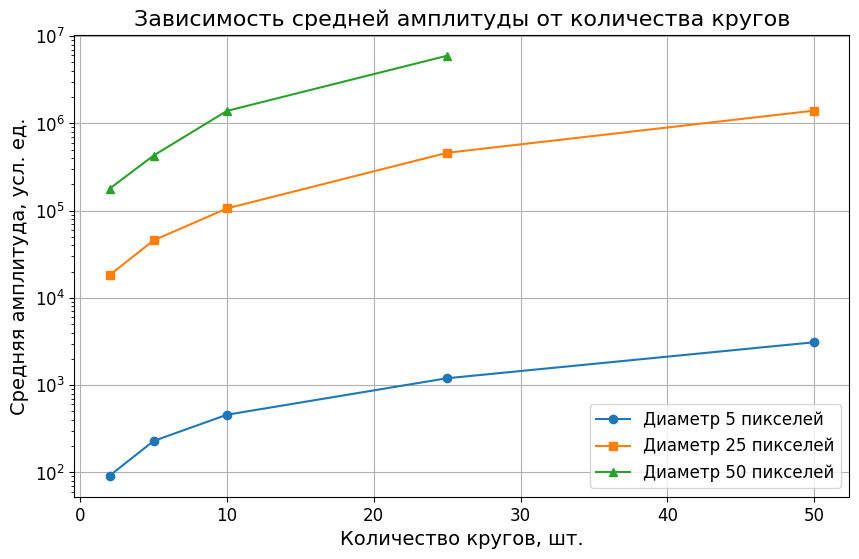

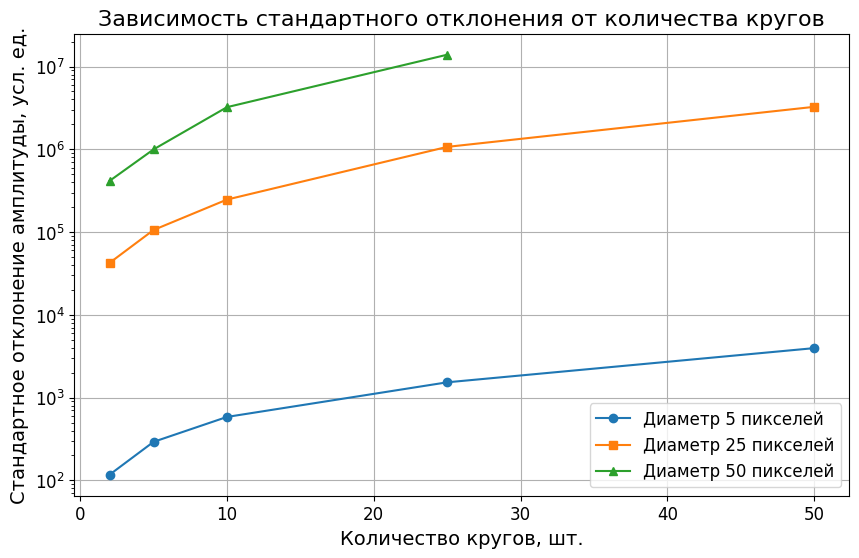

Сгенерированные файлы:
std_ampl_count_plot.png
mean_ampl_diameter_plot.png
area_count_plot.png
mean_ampl_count_plot.png
freq_noise_plot.png
freq_count_plot.png
area_noise_plot.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Данные для одного кружка
diameters = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
areas_1 = [1.15e4, 1.81e5, 1.39e6, 4.64e6, 1.10e7, 2.13e7, 3.68e7, 5.87e7, 8.74e7, 1.24e8, 1.70e8]
freqs_1 = [0.00, 1.71e-2, 3.66e-2, 5.66e-2, 7.59e-2, 9.57e-2, 1.15e-1, 1.36e-1, 1.54e-1, 1.70e-1, 1.94e-1]
mean_ampl_1 = [4.53e1, 7.20e2, 5.63e3, 1.91e4, 4.59e4, 9.08e4, 1.59e5, 2.58e5, 3.91e5, 5.65e5, 7.86e5]
std_ampl_1 = [5.84e1, 1.68e3, 1.94e4, 8.14e4, 2.26e5, 4.99e5, 9.56e5, 1.67e6, 2.69e6, 4.11e6, 6.00e6]

# Данные для количества кружков (диаметры 5, 25, 50 пикселей)
counts_5 = [2, 5, 10, 25, 50]
areas_5 = [2.30e4, 5.76e4, 1.15e5, 3.02e5, 7.81e5]
freqs_5 = [3.12e-1, 3.35e-1, 3.36e-1, 3.08e-1, 3.31e-1]
mean_ampl_5 = [9.16e1, 2.29e2, 4.58e2, 1.20e3, 3.10e3]
std_ampl_5 = [1.17e2, 2.92e2, 5.84e2, 1.53e3, 3.96e3]

counts_25 = [2, 5, 10, 25, 50]
areas_25 = [4.54e6, 1.14e7, 2.65e7, 1.15e8, 3.50e8]
freqs_25 = [1.81e-1, 3.21e-1, 3.04e-1, 2.99e-1, 2.89e-1]
mean_ampl_25 = [1.82e4, 4.56e4, 1.06e5, 4.60e5, 1.40e6]
std_ampl_25 = [4.24e4, 1.06e5, 2.47e5, 1.07e6, 3.26e6]

counts_50 = [2, 5, 10, 25]
areas_50 = [4.44e7, 1.07e8, 3.47e8, 1.49e9]
freqs_50 = [1.55e-1, 2.96e-1, 2.93e-1, 2.74e-1]
mean_ampl_50 = [1.78e5, 4.28e5, 1.39e6, 5.96e6]
std_ampl_50 = [4.15e5, 9.98e5, 3.23e6, 1.39e7]

# Данные для шума (30, 40, 50 пикселей, 10 кружков)
noise_diam = [0, 2, 3, 4, 5]
areas_noise = [3.62e8, 9.62e8, 1.10e9, 1.12e9, 1.03e9]
freqs_noise = [3.23e-1, 3.28e-1, 3.12e-1, 3.32e-1, 3.21e-1]
mean_ampl_noise = [2.43e6, 6.45e6, 7.37e6, 7.50e6, 6.91e6]
std_ampl_noise = [3.26e7, 8.66e7, 9.90e7, 1.01e8, 9.27e7]

# Рисунок 1: Площадь от количества кругов
plt.figure(figsize=(10, 6))
plt.plot(counts_5, areas_5, 'o-', label='Диаметр 5 пикселей')
plt.plot(counts_25, areas_25, 's-', label='Диаметр 25 пикселей')
plt.plot(counts_50, areas_50, '^-', label='Диаметр 50 пикселей')
plt.xlabel('Количество кругов, шт.', fontsize=14)
plt.ylabel('Площадь под радиальным срезом, усл. ед.', fontsize=14)
plt.title('Зависимость площади от количества кругов', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/area_count_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Рисунок 2: Частота максимума от количества кругов
plt.figure(figsize=(10, 6))
plt.plot(counts_5, freqs_5, 'o-', label='Диаметр 5 пикселей')
plt.plot(counts_25, freqs_25, 's-', label='Диаметр 25 пикселей')
plt.plot(counts_50, freqs_50, '^-', label='Диаметр 50 пикселей')
plt.xlabel('Количество кругов, шт.', fontsize=14)
plt.ylabel('Частота максимума, 1/пиксель', fontsize=14)
plt.title('Зависимость частоты максимума от количества кругов', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/freq_count_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Рисунок 3: Площадь от диаметра шума
plt.figure(figsize=(10, 6))
plt.plot(noise_diam, areas_noise, 'o-', label='30, 40, 50 пикселей, 10 кругов')
plt.xlabel('Диаметр шума, пиксели', fontsize=14)
plt.ylabel('Площадь под радиальным срезом, усл. ед.', fontsize=14)
plt.title('Зависимость площади от диаметра шума', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/area_noise_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Рисунок 4: Частота максимума от диаметра шума
plt.figure(figsize=(10, 6))
plt.plot(noise_diam, freqs_noise, 'o-', label='30, 40, 50 пикселей, 10 кругов')
plt.xlabel('Диаметр шума, пиксели', fontsize=14)
plt.ylabel('Частота максимума, 1/пиксель', fontsize=14)
plt.title('Зависимость частоты максимума от диаметра шума', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/freq_noise_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Рисунок 5: Средняя амплитуда от диаметра (одиночный объект)
plt.figure(figsize=(10, 6))
plt.plot(diameters, mean_ampl_1, 'o-')
plt.xlabel('Диаметр, пиксели', fontsize=14)
plt.ylabel('Средняя амплитуда, усл. ед.', fontsize=14)
plt.title('Зависимость средней амплитуды от диаметра', fontsize=16)
plt.grid(True)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/mean_ampl_diameter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Рисунок 6: Средняя амплитуда от количества кругов
plt.figure(figsize=(10, 6))
plt.plot(counts_5, mean_ampl_5, 'o-', label='Диаметр 5 пикселей')
plt.plot(counts_25, mean_ampl_25, 's-', label='Диаметр 25 пикселей')
plt.plot(counts_50, mean_ampl_50, '^-', label='Диаметр 50 пикселей')
plt.xlabel('Количество кругов, шт.', fontsize=14)
plt.ylabel('Средняя амплитуда, усл. ед.', fontsize=14)
plt.title('Зависимость средней амплитуды от количества кругов', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/mean_ampl_count_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Рисунок 7: Стандартное отклонение от количества кругов
plt.figure(figsize=(10, 6))
plt.plot(counts_5, std_ampl_5, 'o-', label='Диаметр 5 пикселей')
plt.plot(counts_25, std_ampl_25, 's-', label='Диаметр 25 пикселей')
plt.plot(counts_50, std_ampl_50, '^-', label='Диаметр 50 пикселей')
plt.xlabel('Количество кругов, шт.', fontsize=14)
plt.ylabel('Стандартное отклонение амплитуды, усл. ед.', fontsize=14)
plt.title('Зависимость стандартного отклонения от количества кругов', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=12)
plt.savefig('/kaggle/working/std_ampl_count_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Проверка наличия файлов
print("Сгенерированные файлы:")
for file in os.listdir('/kaggle/working'):
    if file.endswith('.png'):
        print(file)

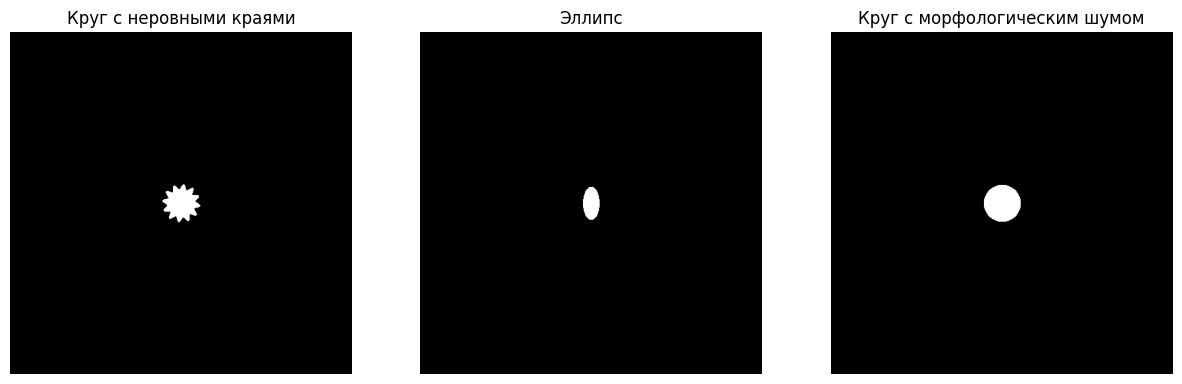

Нулевой максимум: амплитуда = 9.47e+05, частота = 0.00e+00 1/пиксель
Первый максимум: r = 34, амплитуда = 1.67e+04, частота = 6.64e-02 1/пиксель
Первый минимум: r = 25, амплитуда = 9.52e-01, частота = 4.88e-02 1/пиксель


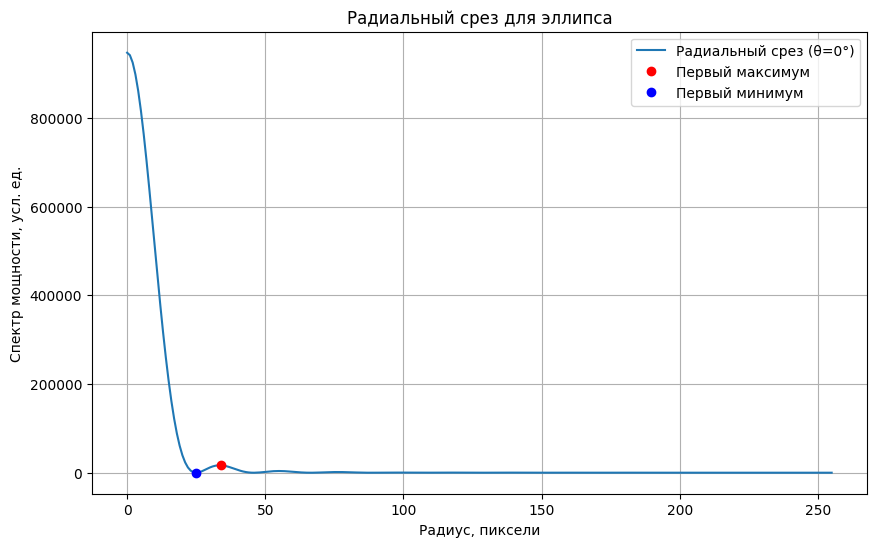

Сгенерированные файлы:
radial_profile_ellipse.png
std_ampl_count_plot.png
mean_ampl_diameter_plot.png
area_count_plot.png
mean_ampl_count_plot.png
freq_noise_plot.png
freq_count_plot.png
irregular_shapes.png
area_noise_plot.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import ellipse, disk
from skimage.morphology import dilation, disk as morph_disk
import os

# Параметры изображения
N = 512  # Размер изображения 512x512
center = (N//2, N//2)  # Центр объекта
diameter = 50  # Средний диаметр объекта
img = np.zeros((N, N), dtype=np.uint8)

# 1. Круг с неровными краями (синусоидальные пертурбации)
def draw_irregular_circle(img, center, radius, amplitude=0.1, frequency=10):
    """
    Рисует круг с неровными краями, добавляя синусоидальные вариации радиуса.
    amplitude: относительная амплитуда вариаций (0.1 = 10% радиуса)
    frequency: количество "волн" по окружности
    """
    rr, cc = np.indices((N, N))
    rr = rr - center[0]
    cc = cc - center[1]
    theta = np.arctan2(rr, cc)
    r = np.sqrt(rr**2 + cc**2)
    # Вариация радиуса: r = radius + radius * amplitude * sin(frequency * theta)
    radius_varied = radius + radius * amplitude * np.sin(frequency * theta)
    mask = r <= radius_varied
    img[mask] = 1
    return img

# 2. Эллипс (вытянутая форма)
def draw_ellipse(img, center, r_radius, c_radius):
    """
    Рисует эллипс с радиусами r_radius (по y) и c_radius (по x).
    """
    rr, cc = ellipse(center[0], center[1], r_radius, c_radius, shape=(N, N))
    img[rr, cc] = 1
    return img

# 3. Добавление случайных искажений (морфологические операции)
def add_morphological_noise(img, selem_radius=2):
    """
    Добавляет случайные неровности через дилатацию с небольшим структурным элементом.
    """
    selem = morph_disk(selem_radius)
    noisy_img = dilation(img, selem)
    return noisy_img

# Генерация изображения
# Случай 1: Круг с неровными краями
img_irregular = draw_irregular_circle(np.zeros((N, N), dtype=np.uint8), center, radius=diameter/2, amplitude=0.15, frequency=12)

# Случай 2: Эллипс
img_ellipse = draw_ellipse(np.zeros((N, N), dtype=np.uint8), center, r_radius=diameter/2, c_radius=diameter/4)  # Вытянутый по оси x

# Случай 3: Круг с морфологическим шумом
img_circle = np.zeros((N, N), dtype=np.uint8)
rr, cc = disk(center, diameter/2, shape=(N, N))
img_circle[rr, cc] = 1
img_noisy = add_morphological_noise(img_circle, selem_radius=3)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_irregular, cmap='gray')
axes[0].set_title('Круг с неровными краями')
axes[1].imshow(img_ellipse, cmap='gray')
axes[1].set_title('Эллипс')
axes[2].imshow(img_noisy, cmap='gray')
axes[2].set_title('Круг с морфологическим шумом')
for ax in axes:
    ax.axis('off')
plt.savefig('/kaggle/working/irregular_shapes.png', dpi=300, bbox_inches='tight')
plt.show()

# Вычисление радиального среза для эллипса (пример)
F = np.fft.fft2(img_ellipse)
F_shifted = np.fft.fftshift(F)
power_spectrum = np.abs(F_shifted)**2
radial_profile = power_spectrum[N//2, N//2:N//2+N//2]  # Срез при θ=0°
radii = np.arange(0, N//2)

# Поиск первого максимума и минимума
from scipy.signal import find_peaks
peaks, _ = find_peaks(radial_profile)
minima, _ = find_peaks(-radial_profile)

# Нулевой максимум
zero_max_amplitude = power_spectrum[N//2, N//2]
zero_max_frequency = 0.0

# Первый максимум и минимум
if len(peaks) > 0:
    first_peak_r = peaks[0]
    first_peak_amplitude = radial_profile[first_peak_r]
    first_peak_frequency = first_peak_r / N
else:
    first_peak_r, first_peak_amplitude, first_peak_frequency = None, None, None

if len(minima) > 0:
    first_min_r = minima[0]
    first_min_amplitude = radial_profile[first_min_r]
    first_min_frequency = first_min_r / N
else:
    first_min_r, first_min_amplitude, first_min_frequency = None, None, None

# Вывод результатов
print(f"Нулевой максимум: амплитуда = {zero_max_amplitude:.2e}, частота = {zero_max_frequency:.2e} 1/пиксель")
print(f"Первый максимум: r = {first_peak_r}, амплитуда = {first_peak_amplitude:.2e}, частота = {first_peak_frequency:.2e} 1/пиксель")
print(f"Первый минимум: r = {first_min_r}, амплитуда = {first_min_amplitude:.2e}, частота = {first_min_frequency:.2e} 1/пиксель")

# Сохранение радиального среза
plt.figure(figsize=(10, 6))
plt.plot(radii, radial_profile, label='Радиальный срез (θ=0°)')
if len(peaks) > 0:
    plt.plot(first_peak_r, first_peak_amplitude, 'ro', label='Первый максимум')
if len(minima) > 0:
    plt.plot(first_min_r, first_min_amplitude, 'bo', label='Первый минимум')
plt.xlabel('Радиус, пиксели')
plt.ylabel('Спектр мощности, усл. ед.')
plt.title('Радиальный срез для эллипса')
plt.grid(True)
plt.legend()
plt.savefig('/kaggle/working/radial_profile_ellipse.png', dpi=300, bbox_inches='tight')
plt.show()

# Проверка файлов
print("Сгенерированные файлы:")
for file in os.listdir('/kaggle/working'):
    if file.endswith('.png'):
        print(file)

First Maximum: Frequency = 16 pixels, Magnitude Squared = 4.62e+09
First Minimum: Frequency = 12 pixels, Magnitude Squared = 9.37e+07


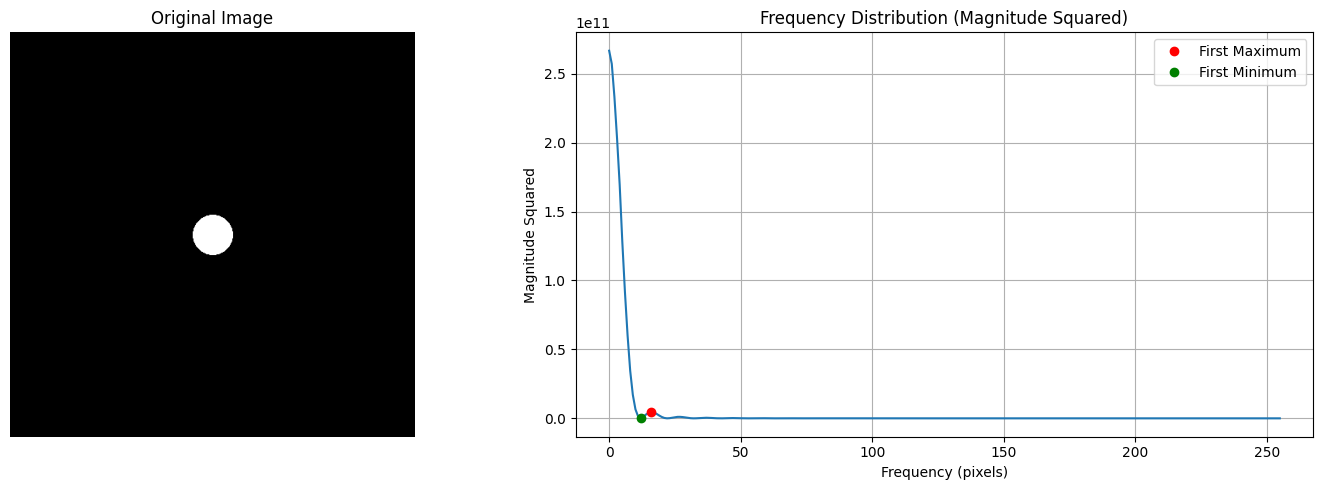

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from scipy.signal import argrelextrema

# Создаем изображение 512x512 с черным фоном и белым кругом
def create_circle_image():
    width, height = 512, 512
    circle_diameter = 50
    circle_radius = circle_diameter // 2
    
    image = Image.new('L', (width, height), 0)  # 'L' - градации серого, 0 - черный
    draw = ImageDraw.Draw(image)
    
    center_x, center_y = width // 2, height // 2
    
    draw.ellipse(
        [center_x - circle_radius, center_y - circle_radius,
         center_x + circle_radius, center_y + circle_radius],
        fill=255  # 255 - белый
    )
    
    return np.array(image)

# Вычисляем радиальный профиль FFT
def radial_profile(fft_data, center):
    y, x = np.indices(fft_data.shape)
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)
    
    # Усредняем амплитуды по радиусу
    tbin = np.bincount(r.ravel(), fft_data.ravel()) / np.bincount(r.ravel())
    return tbin

# Создаем изображение
img = create_circle_image()

# Вычисляем 2D FFT
fft = np.fft.fft2(img)
fft_shifted = np.fft.fftshift(fft)  # Сдвиг для центрирования
fft_magnitude = np.abs(fft_shifted) ** 2  # Квадрат модуля

# Вычисляем радиальный профиль
center = (fft_magnitude.shape[1] // 2, fft_magnitude.shape[0] // 2)
freq_dist = radial_profile(fft_magnitude, center)

# Частоты в пикселях (без нормализации)
max_freq = min(img.shape) // 2
frequencies = np.arange(len(freq_dist))

# Находим первый максимум и минимум
maxima = argrelextrema(freq_dist[:max_freq], np.greater, order=5)[0]
minima = argrelextrema(freq_dist[:max_freq], np.less, order=5)[0]

first_max_idx = maxima[0] if len(maxima) > 0 else None
first_min_idx = minima[0] if len(minima) > 0 else None

# Выводим значения
if first_max_idx is not None:
    print(f"First Maximum: Frequency = {frequencies[first_max_idx]} pixels, Magnitude Squared = {freq_dist[first_max_idx]:.2e}")
if first_min_idx is not None:
    print(f"First Minimum: Frequency = {frequencies[first_min_idx]} pixels, Magnitude Squared = {freq_dist[first_min_idx]:.2e}")

# Создаем фигуру с двумя подграфиками
plt.figure(figsize=(15, 5))

# Оригинальное изображение
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# График распределения частот
plt.subplot(1, 2, 2)
plt.plot(frequencies[:max_freq], freq_dist[:max_freq])
plt.title('Frequency Distribution (Magnitude Squared)')
plt.xlabel('Frequency (pixels)')
plt.ylabel('Magnitude Squared')
plt.grid(True)

# Отмечаем первый максимум и минимум
if first_max_idx is not None:
    plt.plot(frequencies[first_max_idx], freq_dist[first_max_idx], 'ro', label='First Maximum')
if first_min_idx is not None:
    plt.plot(frequencies[first_min_idx], freq_dist[first_min_idx], 'go', label='First Minimum')
plt.legend()

plt.tight_layout()
plt.show()

# Сохраняем изображения
Image.fromarray(img).save('circle_image.png')
np.savetxt('frequency_distribution.txt', np.column_stack((frequencies[:max_freq], freq_dist[:max_freq])), header='Frequency_(pixels) Magnitude_Squared')

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import random
import json
from scipy.ndimage import gaussian_filter
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Button, VBox, HBox, Output

# Установка и активация ipywidgets (выполните в отдельной ячейке, если нужно):
# !pip install ipywidgets
# !jupyter nbextension enable --py widgetsnbextension --sys-prefix

# Создаем папку для сохранения результатов
output_dir = "/kaggle/working/Test_spectrum"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Параметры изображения
image_size = 512  # Размер изображения 512x512 пикселей
pixel_size_um = 0.25  # 1 пиксель = 0.25 мкм
max_freq = 0.5  # Ограничение частоты для графика (1/мкм)

# Функция для проверки пересечения кругов
def circles_intersect(x1, y1, r1, x2, y2, r2):
    distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return distance < (r1 + r2)

# Функция для анализа спектра Фурье (квадрат модуля)
def analyze_fourier_spectrum(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    power_spectrum = np.abs(f_shift)**2  # Квадрат модуля спектра
    
    freqs = np.fft.fftfreq(image_size, d=pixel_size_um)
    freqs_shift = np.fft.fftshift(freqs)
    center = image_size // 2
    radial_profile = np.mean([power_spectrum[center, center:], power_spectrum[center:, center]], axis=0)
    
    # Ограничиваем частоты до max_freq (0.5 1/мкм)
    valid_indices = np.where(freqs_shift[center:] <= max_freq)[0]
    radial_profile = radial_profile[valid_indices]
    freqs_limited = freqs_shift[center:][valid_indices]
    
    # Поиск пиков
    peaks = np.where((radial_profile[1:-1] > radial_profile[:-2]) & (radial_profile[1:-1] > radial_profile[2:]))[0] + 1
    
    diameters_um = []
    for peak in peaks:
        freq = abs(freqs_limited[peak])
        if freq > 0:
            diameter_um = 1 / freq
            diameters_um.append(diameter_um)
    
    return power_spectrum, radial_profile, freqs_limited, diameters_um

# Функция для генерации изображения
def generate_image(diameter1_um, count1, diameter2_um, count2, noise_type, noise_level, spot_size_um):
    image = np.zeros((image_size, image_size), dtype=np.uint8)
    circle_positions = []
    
    # Параметры кругов
    circle_params = [
        {"diameter_um": diameter1_um, "count": count1},
        {"diameter_um": diameter2_um, "count": count2}
    ]
    
    # Генерация кругов
    for param in circle_params:
        diameter_px = param["diameter_um"] / pixel_size_um
        radius_px = diameter_px / 2
        count = param["count"]
        
        for _ in range(count):
            attempts = 0
            max_attempts = 1000
            placed = False
            
            while not placed and attempts < max_attempts:
                x = random.randint(int(radius_px), int(image_size - radius_px))
                y = random.randint(int(radius_px), int(image_size - radius_px))
                
                intersects = False
                for cx, cy, cr in circle_positions:
                    if circles_intersect(x, y, radius_px, cx, cy, cr):
                        intersects = True
                        break
                
                if not intersects:
                    y_grid, x_grid = np.ogrid[:image_size, :image_size]
                    distance = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
                    image[distance <= radius_px] = 255
                    circle_positions.append((x, y, radius_px))
                    placed = True
                attempts += 1
    
    # Добавление шума
    if noise_type == "Pixel":
        num_noise_pixels = int(image_size * image_size * noise_level)
        noise_x = np.random.randint(0, image_size, num_noise_pixels)
        noise_y = np.random.randint(0, image_size, num_noise_pixels)
        image[noise_y, noise_x] = 255
    elif noise_type == "Gaussian":
        noise = np.random.normal(0, noise_level * 255, (image_size, image_size))
        image = np.clip(image + noise, 0, 255).astype(np.uint8)
        image = (image > 127).astype(np.uint8) * 255
    elif noise_type == "Spots":
        spot_radius_px = spot_size_um / pixel_size_um / 2
        num_spots = int(image_size * image_size * noise_level / (np.pi * spot_radius_px**2))
        for _ in range(num_spots):
            x = random.randint(int(spot_radius_px), int(image_size - spot_radius_px))
            y = random.randint(int(spot_radius_px), int(image_size - spot_radius_px))
            y_grid, x_grid = np.ogrid[:image_size, :image_size]
            distance = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
            image[distance <= spot_radius_px] = 255
    
    # Вычисление параметров
    total_circles = len(circle_positions)
    diameters_px = [2 * r for _, _, r in circle_positions]
    diameters_um = [d * pixel_size_um for d in diameters_px]
    mean_diameter_um = np.mean(diameters_um) if diameters_um else 0
    coverage = np.sum(image == 255) / (image_size * image_size)
    
    counts_by_diameter = {param["diameter_um"]: param["count"] for param in circle_params}
    
    # Анализ спектра Фурье
    power_spectrum, radial_profile, freqs, estimated_diameters = analyze_fourier_spectrum(image)
    
    # Сохранение изображения
    output_filename = f"circles_d{diameter1_um}um_{count1}_d{diameter2_um}um_{count2}_{noise_type}_noise{noise_level:.3f}.png"
    output_path = os.path.join(output_dir, output_filename)
    Image.fromarray(image).save(output_path)
    
    # Сохранение спектра
    spectrum_filename = output_filename.replace(".png", "_spectrum.png")
    spectrum_path = os.path.join(output_dir, spectrum_filename)
    plt.imsave(spectrum_path, np.log1p(power_spectrum), cmap='viridis')
    
    # Сохранение параметров в JSON
    params = {
        "circle_params": circle_params,
        "noise_type": noise_type,
        "noise_level": noise_level,
        "spot_size_um": spot_size_um if noise_type == "Spots" else None,
        "total_circles": total_circles,
        "counts_by_diameter": counts_by_diameter,
        "mean_diameter_um": mean_diameter_um,
        "coverage": coverage,
        "estimated_diameters_um": estimated_diameters
    }
    json_path = os.path.join(output_dir, output_filename.replace(".png", ".json"))
    with open(json_path, "w") as f:
        json.dump(params, f, indent=4)
    
    # Визуализация
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Circles: {counts_by_diameter}\nNoise: {noise_type}, {noise_level*100:.1f}%")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(np.log1p(power_spectrum), cmap='viridis')
    plt.title("Power Spectrum (|F|^2, log scale)")
    plt.axis('off')
    plt.colorbar(label='Log Power')
    
    plt.subplot(1, 3, 3)
    plt.plot(freqs, radial_profile)
    plt.title("Radial Frequency Profile (up to 0.5 1/μm)")
    plt.xlabel("Spatial Frequency (1/μm)")
    plt.ylabel("Power (|F|^2)")
    #for peak in estimated_diameters:
   #     if peak > 0 and 1/peak <= max_freq:
   #         plt.axvline(x=1/peak, color='red', linestyle='--', alpha=0.5, label=f'Diameter: {peak:.2f} μm')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод параметров
    print(f"Изображение сохранено: {output_path}")
    print(f"Спектр сохранен: {spectrum_path}")
    print(f"Параметры сохранены: {json_path}")
    print(f"Общее количество кругов: {total_circles}")
    print(f"Круги по диаметрам: {counts_by_diameter}")
    print(f"Средний диаметр: {mean_diameter_um:.2f} мкм")
    print(f"Доля покрытия: {coverage*100:.2f}%")
    print(f"Уровень шума: {noise_level*100:.1f}%")
    print(f"Оцененные диаметры из спектра: {[f'{d:.2f}' for d in estimated_diameters]} мкм")
    
    return image, params

# Интерактивный интерфейс
output = Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        generate_image(
            diameter1_um=diameter1_slider.value,
            count1=count1_slider.value,
            diameter2_um=diameter2_slider.value,
            count2=count2_slider.value,
            noise_type=noise_dropdown.value,
            noise_level=noise_slider.value,
            spot_size_um=spot_size_slider.value
        )

# Виджеты
diameter1_slider = FloatSlider(value=10, min=1, max=20, step=0.5, description="Диаметр 1 (мкм)")
count1_slider = IntSlider(value=5, min=0, max=20, description="Количество 1")
diameter2_slider = FloatSlider(value=5, min=1, max=20, step=0.5, description="Диаметр 2 (мкм)")
count2_slider = IntSlider(value=10, min=0, max=20, description="Количество 2")
noise_dropdown = Dropdown(options=["Pixel", "Gaussian", "Spots"], value="Pixel", description="Тип шума")
noise_slider = FloatSlider(value=0.01, min=0, max=0.1, step=0.001, description="Уровень шума")
spot_size_slider = FloatSlider(value=2, min=0.5, max=5, step=0.5, description="Размер пятен (мкм)")

button = Button(description="Сгенерировать")
button.on_click(on_button_clicked)

# Отображение интерфейса
display(VBox([diameter1_slider, count1_slider, diameter2_slider, count2_slider, 
              noise_dropdown, noise_slider, spot_size_slider, button, output]))

# Для статического запуска (если виджеты не работают):
# Раскомментируйте следующий код и задайте параметры
"""
image, params = generate_image(
    diameter1_um=10,
    count1=5,
    diameter2_um=5,
    count2=10,
    noise_type="Pixel",
    noise_level=0.01,
    spot_size_um=2
)
"""

'\nimage, params = generate_image(\n    diameter1_um=10,\n    count1=5,\n    diameter2_um=5,\n    count2=10,\n    noise_type="Pixel",\n    noise_level=0.01,\n    spot_size_um=2\n)\n'